# HealthIQ — Complete Healthcare Analytics Project

This notebook combines the complete workflow into one executable notebook:

1. **Data Cleaning**
2. **Exploratory Data Analysis (EDA)**
3. **Business Analysis**

# HealthIQ — 01: Data Cleaning

**Objective:** Inspect the raw dataset, document all quality issues, apply cleaning transformations, and save the cleaned dataset.

**Input:** `../data/raw/healthcare_patient_analytics_seaborn.csv`  
**Output:** `../data/processed/cleaned_healthcare_data.csv`

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## 1. Load Raw Data

In [35]:
df_raw = pd.read_csv('../data/raw/healthcare_patient_analytics_seaborn.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head(10)

Shape: (5000, 12)


,patient_id,visit_date,age_group,gender,region,department,treatment_type,visit_type,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
0,1,2022-01-01 00:00:00,31-45,Male,West,General Medicine,Medication,Emergency,5.80,59151.00,59.00,0.12
1,2,2022-01-01 01:00:00,60+,Female,West,Orthopedics,Surgery,Routine,5.10,30272.00,97.00,0.11
2,3,2022-01-01 02:00:00,46-60,Male,South,Pediatrics,Observation,Routine,7.90,67498.00,60.00,0.19
3,4,2022-01-01 03:00:00,31-45,Female,North,Neurology,Medication,Routine,5.00,29896.00,51.00,0.47
4,5,2022-01-01 04:00:00,18-30,Female,North,Neurology,Therapy,Routine,0.00,36208.00,60.00,0.40
5,6,2022-01-01 05:00:00,18-30,Male,North,Neurology,Medication,Routine,5.70,34016.00,96.00,0.07
6,7,2022-01-01 06:00:00,18-30,Female,North,Cardiology,Surgery,Routine,0.80,51496.00,53.00,0.10
7,8,2022-01-01 07:00:00,60+,Female,South,Cardiology,Therapy,Emergency,4.90,47951.00,64.00,0.73
8,9,2022-01-01 08:00:00,46-60,Male,South,Neurology,Observation,Emergency,0.60,54975.00,58.00,0.04
9,10,2022-01-01 09:00:00,46-60,Male,South,General Medicine,Medication,Routine,3.10,36895.00,72.00,0.32


## 2. Basic Inspection

In [36]:
# Data types
df_raw.dtypes

patient_id               int64
visit_date              object
age_group               object
gender                  object
region                  object
department              object
treatment_type          object
visit_type              object
length_of_stay_days    float64
treatment_cost         float64
recovery_score         float64
readmission_risk       float64
dtype: object

In [37]:
# Statistical summary
df_raw.describe(include='all')

,patient_id,visit_date,age_group,gender,region,department,treatment_type,visit_type,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
count,5000.00,5000,5000,5000,5000,5000,5000,5000,5000.00,5000.00,5000.00,5000.00
unique,NaN,5000,4,2,4,5,4,2,NaN,NaN,NaN,NaN
top,NaN,2022-07-28 07:00:00,31-45,Male,West,Orthopedics,Observation,Routine,NaN,NaN,NaN,NaN
freq,NaN,1,1716,2508,1290,1058,1270,3432,NaN,NaN,NaN,NaN
mean,2500.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.06,54915.47,74.72,0.28
std,1443.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.93,19481.16,11.87,0.16
min,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,746.00,33.00,0.01
25%,1250.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.70,41244.75,67.00,0.16
50%,2500.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,55123.50,75.00,0.26
75%,3750.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.40,68012.00,83.00,0.38


## 3. Missing Values

In [38]:
missing = df_raw.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing: {missing.sum()}')

Missing values per column:
patient_id             0
visit_date             0
age_group              0
gender                 0
region                 0
department             0
treatment_type         0
visit_type             0
length_of_stay_days    0
treatment_cost         0
recovery_score         0
readmission_risk       0
dtype: int64

Total missing: 0


**Finding:** No missing values. No imputation required.

## 4. Duplicate Rows

In [39]:
dups = df_raw.duplicated().sum()
print(f'Duplicate rows: {dups}')

Duplicate rows: 0


**Finding:** No duplicates found.

## 5. Categorical Column Inspection

In [40]:
cat_cols = ['age_group', 'gender', 'region', 'department', 'treatment_type', 'visit_type']
for col in cat_cols:
    print(f'--- {col} ---')
    print(df_raw[col].value_counts())
    has_space = (df_raw[col].str.strip() != df_raw[col]).sum()
    print(f'Whitespace issues: {has_space}\n')

--- age_group ---
age_group
31-45    1716
18-30    1283
46-60    1271
60+       730
Name: count, dtype: int64
Whitespace issues: 0

--- gender ---
gender
Male      2508
Female    2492
Name: count, dtype: int64
Whitespace issues: 0

--- region ---
region
West     1290
North    1282
East     1217
South    1211
Name: count, dtype: int64
Whitespace issues: 0

--- department ---
department
Orthopedics         1058
Cardiology           995
General Medicine     991
Pediatrics           989
Neurology            967
Name: count, dtype: int64
Whitespace issues: 0

--- treatment_type ---
treatment_type
Observation    1270
Surgery        1262
Medication     1236
Therapy        1232
Name: count, dtype: int64
Whitespace issues: 0

--- visit_type ---
visit_type
Routine      3432
Emergency    1568
Name: count, dtype: int64
Whitespace issues: 0



## 6. Numerical Validation

In [41]:
print('Negative length_of_stay_days:', (df_raw['length_of_stay_days'] < 0).sum())
print('Negative treatment_cost:', (df_raw['treatment_cost'] < 0).sum())
print('Invalid recovery_score (<0 or >100):', ((df_raw['recovery_score'] < 0) | (df_raw['recovery_score'] > 100)).sum())
print()
print('readmission_risk range:', df_raw['readmission_risk'].min(), 'to', df_raw['readmission_risk'].max())

Negative length_of_stay_days: 0
Negative treatment_cost: 0
Invalid recovery_score (<0 or >100): 0

readmission_risk range: 0.01 to 0.84


## 7. Outlier Detection

In [42]:
num_cols = ['length_of_stay_days', 'treatment_cost', 'recovery_score']
for col in num_cols:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    outliers = df_raw[(df_raw[col] < low) | (df_raw[col] > high)]
    print(f'{col}: {len(outliers)} outliers | bounds [{low:.2f}, {high:.2f}]')

length_of_stay_days: 15 outliers | bounds [-1.35, 9.45]
treatment_cost: 15 outliers | bounds [1093.88, 108162.88]
recovery_score: 18 outliers | bounds [43.00, 107.00]


**Decision:** All outliers are clinically plausible (e.g., LOS up to 11.9 days, costs up to \$119k). They are **retained**.

## 8. Apply Cleaning Transformations

In [43]:
df = df_raw.copy()

# 1. Parse visit_date to datetime
df['visit_date'] = pd.to_datetime(df['visit_date'])

# 2. Strip whitespace from all categorical columns (defensive)
for col in cat_cols:
    df[col] = df[col].str.strip()

# 3. Bin readmission_risk (0–1 float) into Low / Medium / High
bins = [0, 0.3, 0.6, 1.0]
labels = ['Low', 'Medium', 'High']
df['readmission_risk'] = pd.cut(
    df['readmission_risk'], bins=bins, labels=labels, include_lowest=True
).astype(str)

print('Cleaning complete.')
print('Shape:', df.shape)
print('visit_date dtype:', df['visit_date'].dtype)
print('readmission_risk values:', df['readmission_risk'].value_counts().to_dict())

Cleaning complete.
Shape: (5000, 12)
visit_date dtype: datetime64[ns]
readmission_risk values: {'Low': 3002, 'Medium': 1822, 'High': 176}


## 9. Final Dataset Summary

In [44]:
print(f'Original rows: {len(df_raw)}')
print(f'Cleaned rows:  {len(df)}')
print(f'Rows removed:  {len(df_raw) - len(df)}')
print(f'Date range:    {df["visit_date"].min().date()} to {df["visit_date"].max().date()}')
df.head()

Original rows: 5000
Cleaned rows:  5000
Rows removed:  0
Date range:    2022-01-01 to 2022-07-28


,patient_id,visit_date,age_group,gender,region,department,treatment_type,visit_type,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
0,1,2022-01-01 00:00:00,31-45,Male,West,General Medicine,Medication,Emergency,5.80,59151.00,59.00,Low
1,2,2022-01-01 01:00:00,60+,Female,West,Orthopedics,Surgery,Routine,5.10,30272.00,97.00,Low
2,3,2022-01-01 02:00:00,46-60,Male,South,Pediatrics,Observation,Routine,7.90,67498.00,60.00,Low
3,4,2022-01-01 03:00:00,31-45,Female,North,Neurology,Medication,Routine,5.00,29896.00,51.00,Medium
4,5,2022-01-01 04:00:00,18-30,Female,North,Neurology,Therapy,Routine,0.00,36208.00,60.00,Medium


## 10. Save Cleaned Dataset

In [45]:
df.to_csv('../data/processed/cleaned_healthcare_data.csv', index=False)
print('Saved: ../data/processed/cleaned_healthcare_data.csv')

Saved: ../data/processed/cleaned_healthcare_data.csv


# 2. Exploratory Data Analysis


# HealthIQ — 02: Exploratory Data Analysis

**Objective:** Explore patient demographics, hospital operations, financials, outcomes, and variable relationships.

**Input:** `../data/processed/cleaned_healthcare_data.csv`

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.2f}'.format)

df = pd.read_csv('../data/processed/cleaned_healthcare_data.csv', parse_dates=['visit_date'])
print(f'Shape: {df.shape}')
df.head()

Shape: (5000, 12)


,patient_id,visit_date,age_group,gender,region,department,treatment_type,visit_type,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
0,1,2022-01-01 00:00:00,31-45,Male,West,General Medicine,Medication,Emergency,5.80,59151.00,59.00,Low
1,2,2022-01-01 01:00:00,60+,Female,West,Orthopedics,Surgery,Routine,5.10,30272.00,97.00,Low
2,3,2022-01-01 02:00:00,46-60,Male,South,Pediatrics,Observation,Routine,7.90,67498.00,60.00,Low
3,4,2022-01-01 03:00:00,31-45,Female,North,Neurology,Medication,Routine,5.00,29896.00,51.00,Medium
4,5,2022-01-01 04:00:00,18-30,Female,North,Neurology,Therapy,Routine,0.00,36208.00,60.00,Medium


---
## 1. Patient Demographics

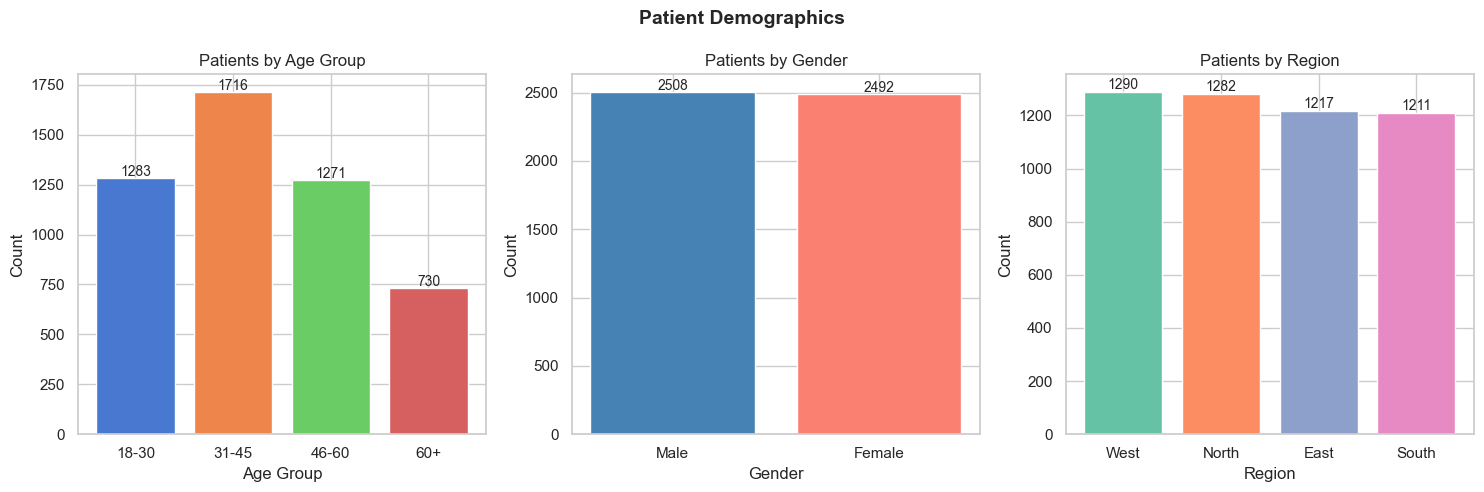

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age group
age_order = ['18-30', '31-45', '46-60', '60+']
age_counts = df['age_group'].value_counts().reindex(age_order)
axes[0].bar(age_counts.index, age_counts.values, color=sns.color_palette('muted', 4))
axes[0].set_title('Patients by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')
for i, v in enumerate(age_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=10)

# Gender
gender_counts = df['gender'].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, color=['steelblue', 'salmon'])
axes[1].set_title('Patients by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=10)

# Region
region_counts = df['region'].value_counts()
axes[2].bar(region_counts.index, region_counts.values, color=sns.color_palette('Set2', 4))
axes[2].set_title('Patients by Region')
axes[2].set_xlabel('Region')
axes[2].set_ylabel('Count')
for i, v in enumerate(region_counts.values):
    axes[2].text(i, v + 10, str(v), ha='center', fontsize=10)

plt.suptitle('Patient Demographics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/charts/01_patient_demographics.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 2. Monthly Visit Trend

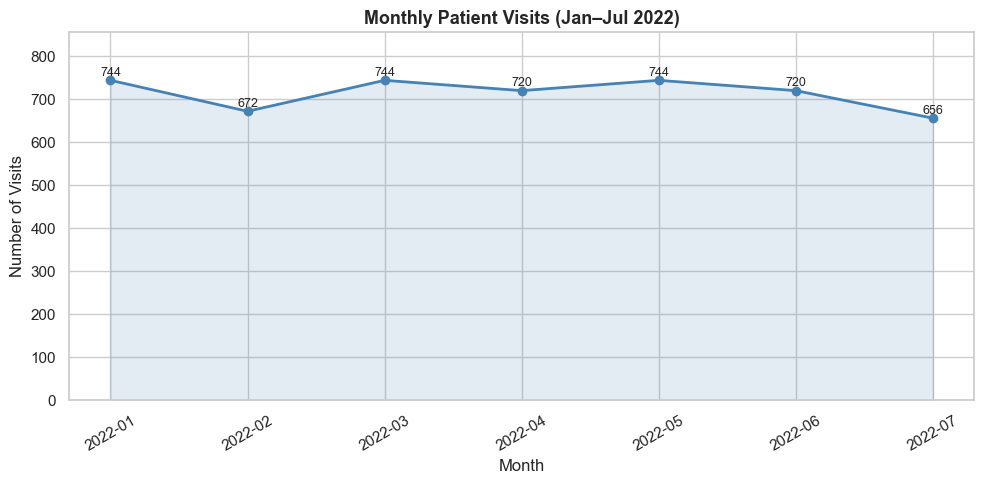

In [48]:
monthly = df.groupby(df['visit_date'].dt.to_period('M')).size().reset_index()
monthly.columns = ['month', 'visits']
monthly['month_str'] = monthly['month'].astype(str)

plt.figure(figsize=(10, 5))
plt.plot(monthly['month_str'], monthly['visits'], marker='o', linewidth=2, color='steelblue')
plt.fill_between(monthly['month_str'], monthly['visits'], alpha=0.15, color='steelblue')
plt.title('Monthly Patient Visits (Jan–Jul 2022)', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Visits')
plt.xticks(rotation=30)
plt.ylim(0, monthly['visits'].max() * 1.15)
for _, row in monthly.iterrows():
    plt.text(row['month_str'], row['visits'] + 10, str(row['visits']), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/charts/02_monthly_visits.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. Department & Visit Type Distribution

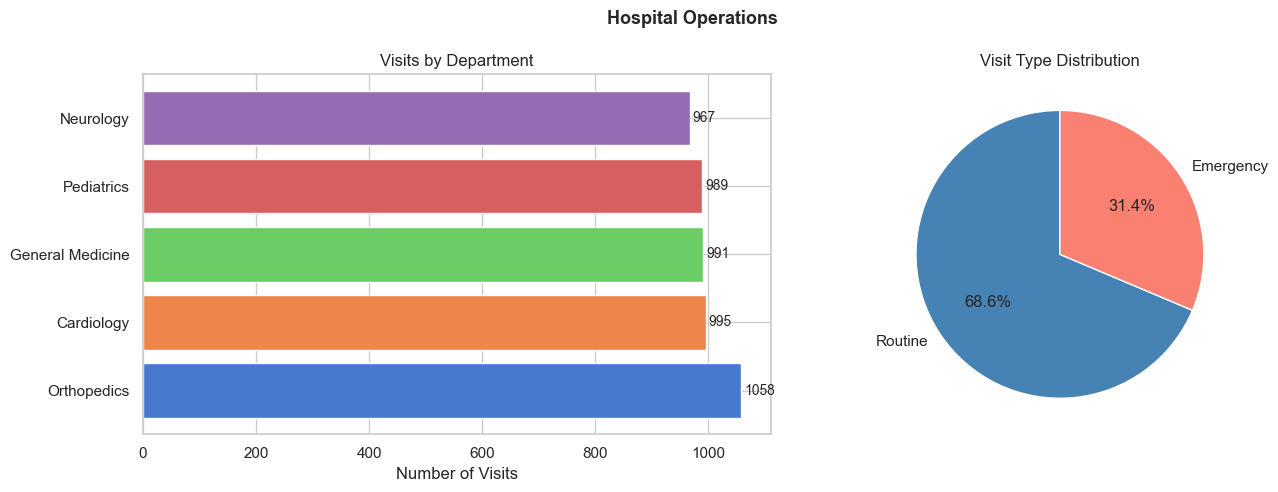

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Department
dept_counts = df['department'].value_counts()
axes[0].barh(dept_counts.index, dept_counts.values, color=sns.color_palette('muted', len(dept_counts)))
axes[0].set_title('Visits by Department')
axes[0].set_xlabel('Number of Visits')
for i, v in enumerate(dept_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=10)

# Visit type
vt_counts = df['visit_type'].value_counts()
axes[1].pie(vt_counts.values, labels=vt_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Visit Type Distribution')

plt.suptitle('Hospital Operations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/charts/03_department_visittype.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. Length of Stay

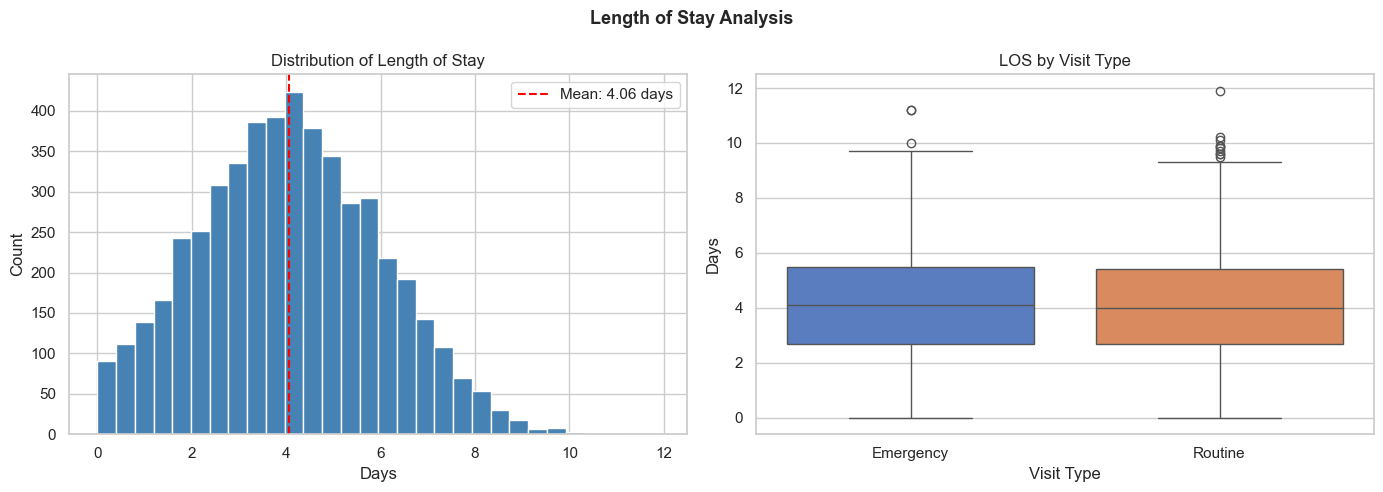

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['length_of_stay_days'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Length of Stay')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Count')
axes[0].axvline(df['length_of_stay_days'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["length_of_stay_days"].mean():.2f} days')
axes[0].legend()

# Boxplot by visit type
dept_order = df.groupby('visit_type')['length_of_stay_days'].mean().sort_values(ascending=False).index
df_plot = df[df['visit_type'].isin(dept_order)]
sns.boxplot(data=df, x='visit_type', y='length_of_stay_days', order=dept_order,
            palette='muted', ax=axes[1])
axes[1].set_title('LOS by Visit Type')
axes[1].set_xlabel('Visit Type')
axes[1].set_ylabel('Days')

plt.suptitle('Length of Stay Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/charts/04_length_of_stay.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Treatment Cost Analysis

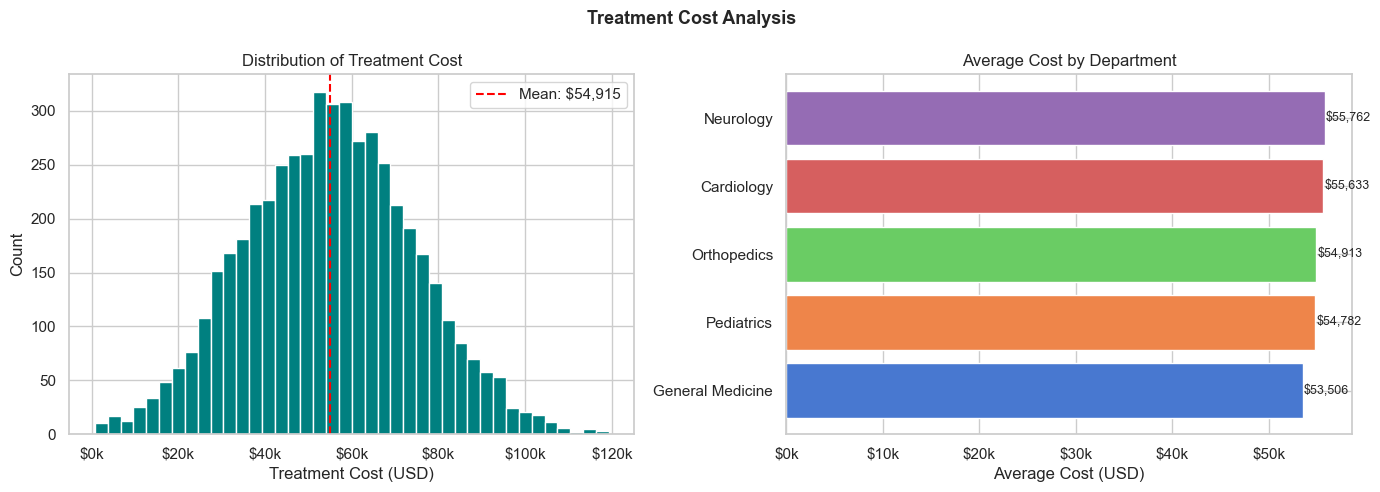

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of treatment cost
axes[0].hist(df['treatment_cost'], bins=40, color='teal', edgecolor='white')
axes[0].set_title('Distribution of Treatment Cost')
axes[0].set_xlabel('Treatment Cost (USD)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['treatment_cost'].mean(), color='red', linestyle='--',
                label=f'Mean: ${df["treatment_cost"].mean():,.0f}')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Avg cost by department
avg_cost_dept = df.groupby('department')['treatment_cost'].mean().sort_values()
axes[1].barh(avg_cost_dept.index, avg_cost_dept.values, color=sns.color_palette('muted', len(avg_cost_dept)))
axes[1].set_title('Average Cost by Department')
axes[1].set_xlabel('Average Cost (USD)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for i, v in enumerate(avg_cost_dept.values):
    axes[1].text(v + 100, i, f'${v:,.0f}', va='center', fontsize=9)

plt.suptitle('Treatment Cost Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/charts/05_treatment_cost.png', dpi=120, bbox_inches='tight')
plt.show()

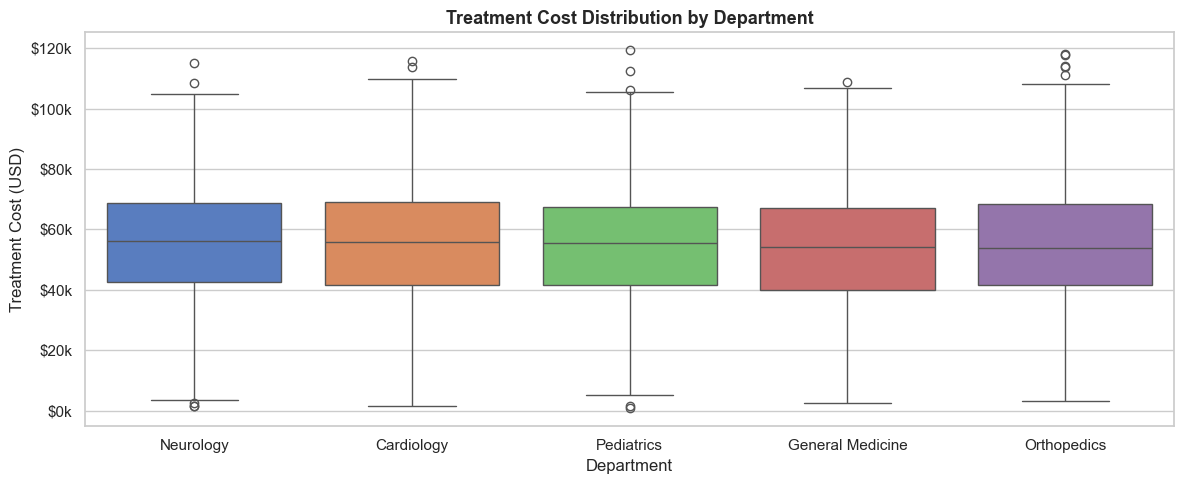

In [52]:
# Boxplot: cost by department
dept_order = df.groupby('department')['treatment_cost'].median().sort_values(ascending=False).index
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='department', y='treatment_cost', order=dept_order, palette='muted')
plt.title('Treatment Cost Distribution by Department', fontsize=13, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Treatment Cost (USD)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('../reports/charts/06_cost_boxplot_dept.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 6. Recovery Score

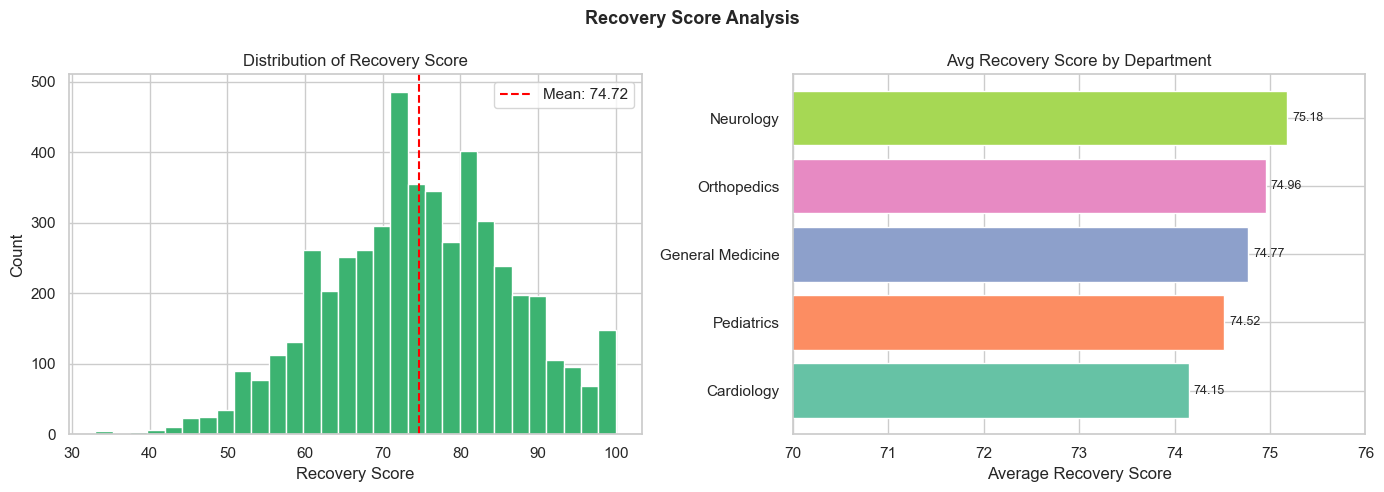

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['recovery_score'], bins=30, color='mediumseagreen', edgecolor='white')
axes[0].axvline(df['recovery_score'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["recovery_score"].mean():.2f}')
axes[0].set_title('Distribution of Recovery Score')
axes[0].set_xlabel('Recovery Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Avg recovery by department
avg_rec = df.groupby('department')['recovery_score'].mean().sort_values()
axes[1].barh(avg_rec.index, avg_rec.values, color=sns.color_palette('Set2', len(avg_rec)))
axes[1].set_title('Avg Recovery Score by Department')
axes[1].set_xlabel('Average Recovery Score')
axes[1].set_xlim(70, 76)
for i, v in enumerate(avg_rec.values):
    axes[1].text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=9)

plt.suptitle('Recovery Score Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/charts/07_recovery_score.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. Readmission Risk Distribution

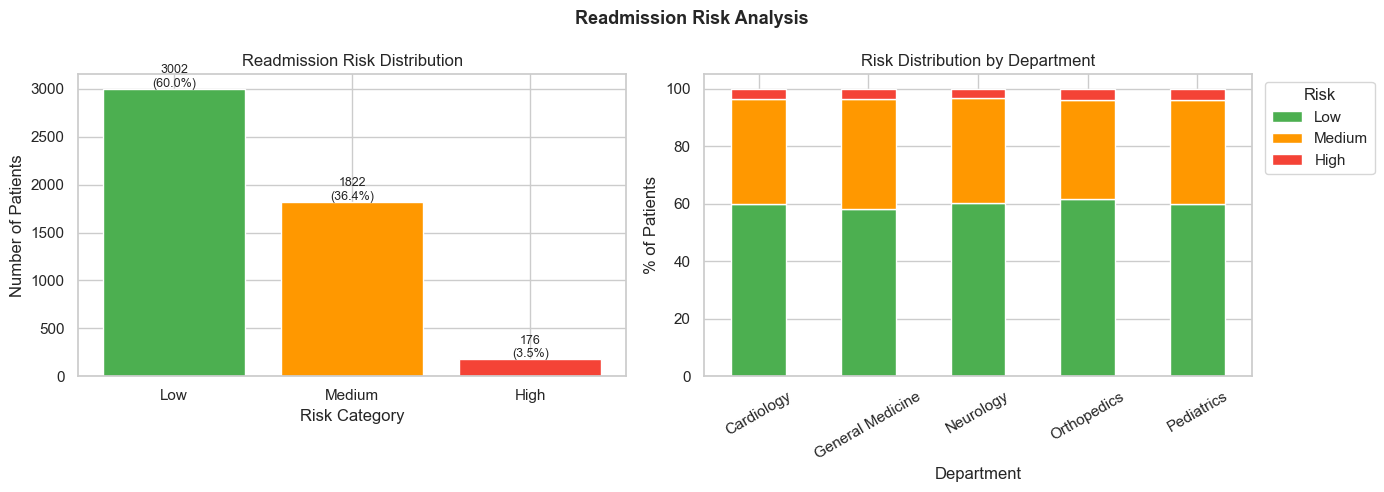

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
risk_order = ['Low', 'Medium', 'High']
risk_colors = ['#4caf50', '#ff9800', '#f44336']

# Overall distribution
risk_counts = df['readmission_risk'].value_counts().reindex(risk_order)
axes[0].bar(risk_counts.index, risk_counts.values, color=risk_colors)
axes[0].set_title('Readmission Risk Distribution')
axes[0].set_xlabel('Risk Category')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(risk_counts.values):
    pct = v / len(df) * 100
    axes[0].text(i, v + 20, f'{v}\n({pct:.1f}%)', ha='center', fontsize=9)

# Risk by department (stacked)
risk_dept = df.groupby(['department', 'readmission_risk']).size().unstack(fill_value=0)
risk_dept = risk_dept[risk_order]
risk_dept_pct = risk_dept.div(risk_dept.sum(axis=1), axis=0) * 100
risk_dept_pct.plot(kind='bar', stacked=True, ax=axes[1], color=risk_colors, edgecolor='white')
axes[1].set_title('Risk Distribution by Department')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('% of Patients')
axes[1].legend(title='Risk', bbox_to_anchor=(1.01, 1))
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Readmission Risk Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/charts/08_readmission_risk.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 8. Correlation Heatmap

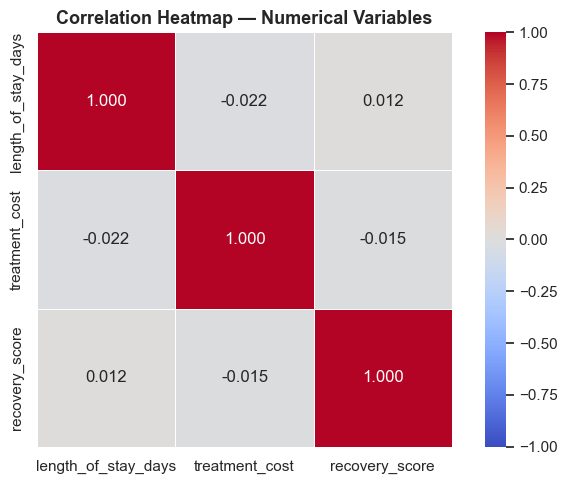


Correlation values:
                     length_of_stay_days  treatment_cost  recovery_score
length_of_stay_days                 1.00           -0.02            0.01
treatment_cost                     -0.02            1.00           -0.01
recovery_score                      0.01           -0.01            1.00


In [55]:
num_df = df[['length_of_stay_days', 'treatment_cost', 'recovery_score']]
corr = num_df.corr()

plt.figure(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/charts/09_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nCorrelation values:')
print(corr.round(3))

---
## 9. Scatter Plots — Relationships Between Variables

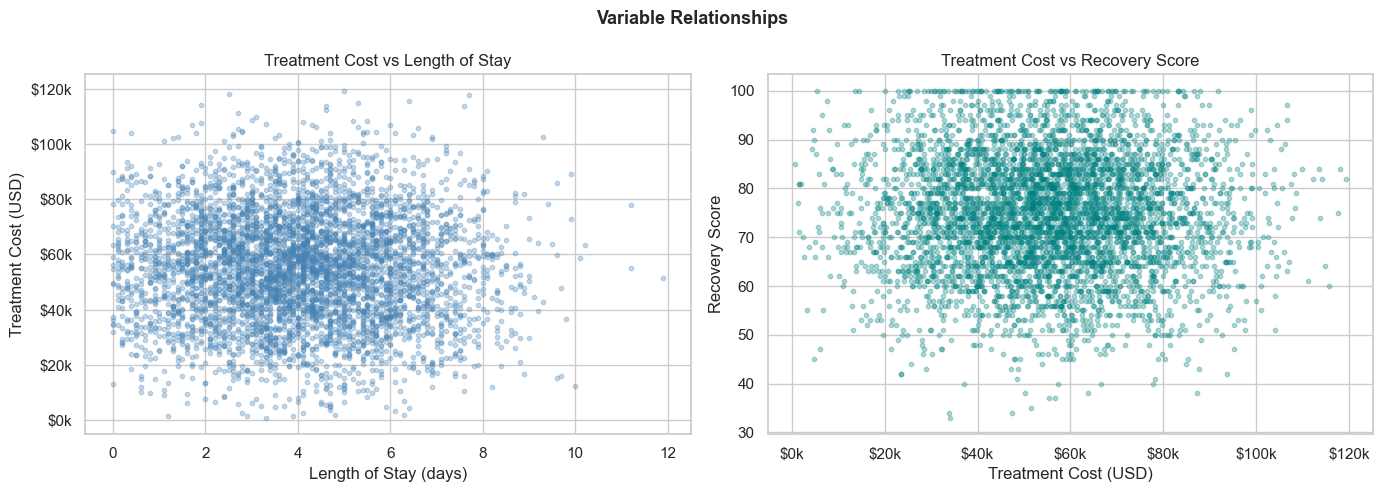

Note: Near-zero correlations indicate no strong linear relationship between these variables.


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cost vs LOS
axes[0].scatter(df['length_of_stay_days'], df['treatment_cost'],
                alpha=0.3, s=10, color='steelblue')
axes[0].set_title('Treatment Cost vs Length of Stay')
axes[0].set_xlabel('Length of Stay (days)')
axes[0].set_ylabel('Treatment Cost (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Cost vs Recovery
axes[1].scatter(df['treatment_cost'], df['recovery_score'],
                alpha=0.3, s=10, color='teal')
axes[1].set_title('Treatment Cost vs Recovery Score')
axes[1].set_xlabel('Treatment Cost (USD)')
axes[1].set_ylabel('Recovery Score')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.suptitle('Variable Relationships', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/charts/10_scatter_plots.png', dpi=120, bbox_inches='tight')
plt.show()

print('Note: Near-zero correlations indicate no strong linear relationship between these variables.')

# 3. Business Analysis


# HealthIQ — 03: Business Analysis

**Objective:** Answer key business questions with data, produce final insights, and create summary visualizations.

**Input:** `../data/processed/cleaned_healthcare_data.csv`

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.2f}'.format)
os.makedirs('../reports/charts', exist_ok=True)

df = pd.read_csv('../data/processed/cleaned_healthcare_data.csv', parse_dates=['visit_date'])
print(f'Loaded {len(df):,} rows')

Loaded 5,000 rows


---
## Patient Analysis

In [58]:
print('=== PATIENT OVERVIEW ===')
print(f'Unique Patients:  {df["patient_id"].nunique():,}')
print(f'Total Visits:     {len(df):,}')
print(f'Date Range:       {df["visit_date"].min().date()} to {df["visit_date"].max().date()}')
print()
print('Visits by Department:')
print(df['department'].value_counts().to_frame('count').assign(pct=lambda x: (x['count']/len(df)*100).round(1)))
print()
print('Visits by Region:')
print(df['region'].value_counts().to_frame('count').assign(pct=lambda x: (x['count']/len(df)*100).round(1)))
print()
print('Visit Types:')
print(df['visit_type'].value_counts().to_frame('count').assign(pct=lambda x: (x['count']/len(df)*100).round(1)))

=== PATIENT OVERVIEW ===
Unique Patients:  5,000
Total Visits:     5,000
Date Range:       2022-01-01 to 2022-07-28

Visits by Department:
                  count   pct
department                   
Orthopedics        1058 21.20
Cardiology          995 19.90
General Medicine    991 19.80
Pediatrics          989 19.80
Neurology           967 19.30

Visits by Region:
        count   pct
region             
West     1290 25.80
North    1282 25.60
East     1217 24.30
South    1211 24.20

Visit Types:
            count   pct
visit_type             
Routine      3432 68.60
Emergency    1568 31.40


---
## Cost Analysis

In [59]:
print('=== COST ANALYSIS ===')
print(f'Total Treatment Cost:   ${df["treatment_cost"].sum():,.0f}')
print(f'Average Treatment Cost: ${df["treatment_cost"].mean():,.0f}')
print(f'Median Treatment Cost:  ${df["treatment_cost"].median():,.0f}')
print()
print('Avg Cost by Department:')
print(df.groupby('department')['treatment_cost'].mean().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))
print()
print('Avg Cost by Treatment Type:')
print(df.groupby('treatment_type')['treatment_cost'].mean().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))
print()
print('Avg Cost by Visit Type:')
print(df.groupby('visit_type')['treatment_cost'].mean().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))

=== COST ANALYSIS ===
Total Treatment Cost:   $274,577,359
Average Treatment Cost: $54,915
Median Treatment Cost:  $55,124

Avg Cost by Department:
department
Neurology           $55,762
Cardiology          $55,633
Orthopedics         $54,913
Pediatrics          $54,782
General Medicine    $53,506
Name: treatment_cost, dtype: object

Avg Cost by Treatment Type:
treatment_type
Surgery        $55,327
Medication     $55,112
Observation    $54,958
Therapy        $54,252
Name: treatment_cost, dtype: object

Avg Cost by Visit Type:
visit_type
Routine      $55,012
Emergency    $54,705
Name: treatment_cost, dtype: object


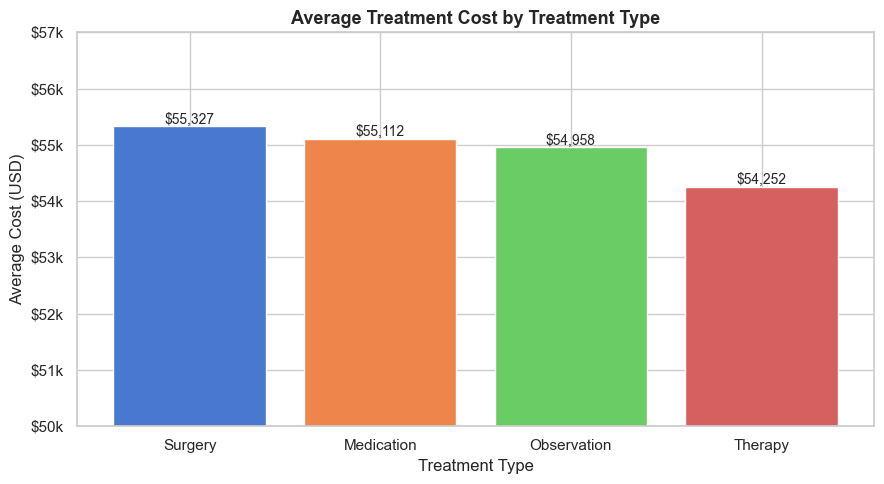

In [60]:
# Cost by treatment type — bar chart
avg_cost_tx = df.groupby('treatment_type')['treatment_cost'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.bar(avg_cost_tx.index, avg_cost_tx.values, color=sns.color_palette('muted', len(avg_cost_tx)))
plt.title('Average Treatment Cost by Treatment Type', fontsize=13, fontweight='bold')
plt.xlabel('Treatment Type')
plt.ylabel('Average Cost (USD)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.ylim(50000, 57000)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'${bar.get_height():,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/charts/11_cost_by_treatment.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Operational Analysis

In [61]:
print('=== OPERATIONS ===')
print(f'Overall Avg LOS: {df["length_of_stay_days"].mean():.2f} days')
print()
print('Avg LOS by Department:')
print(df.groupby('department')['length_of_stay_days'].mean().sort_values(ascending=False).round(2))
print()
print('Avg LOS by Visit Type:')
print(df.groupby('visit_type')['length_of_stay_days'].mean().sort_values(ascending=False).round(2))

=== OPERATIONS ===
Overall Avg LOS: 4.06 days

Avg LOS by Department:
department
Pediatrics         4.14
General Medicine   4.07
Neurology          4.06
Cardiology         4.03
Orthopedics        4.01
Name: length_of_stay_days, dtype: float64

Avg LOS by Visit Type:
visit_type
Emergency   4.10
Routine     4.04
Name: length_of_stay_days, dtype: float64


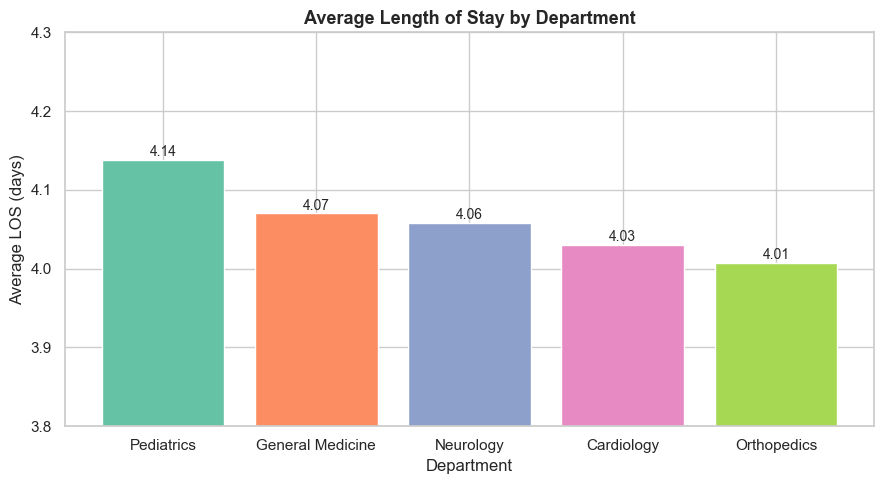

In [62]:
# Avg LOS by department — bar chart
los_dept = df.groupby('department')['length_of_stay_days'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.bar(los_dept.index, los_dept.values, color=sns.color_palette('Set2', len(los_dept)))
plt.title('Average Length of Stay by Department', fontsize=13, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Average LOS (days)')
plt.ylim(3.8, 4.3)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/charts/12_los_by_department.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Risk Analysis

In [63]:
print('=== READMISSION RISK ===')
risk_counts = df['readmission_risk'].value_counts()
risk_order = ['High', 'Medium', 'Low']
for r in risk_order:
    print(f'{r}: {risk_counts[r]:,} ({risk_counts[r]/len(df)*100:.1f}%)')
print()
print('Risk % by Department (High):')
dept_risk = df[df['readmission_risk']=='High'].groupby('department').size() / df.groupby('department').size() * 100
print(dept_risk.sort_values(ascending=False).round(2))
print()
print('Avg Recovery by Risk:')
print(df.groupby('readmission_risk')['recovery_score'].mean().round(2))

=== READMISSION RISK ===
High: 176 (3.5%)
Medium: 1,822 (36.4%)
Low: 3,002 (60.0%)

Risk % by Department (High):
department
Orthopedics        3.78
Pediatrics         3.74
General Medicine   3.53
Cardiology         3.42
Neurology          3.10
dtype: float64

Avg Recovery by Risk:
readmission_risk
High     73.81
Low      74.71
Medium   74.82
Name: recovery_score, dtype: float64


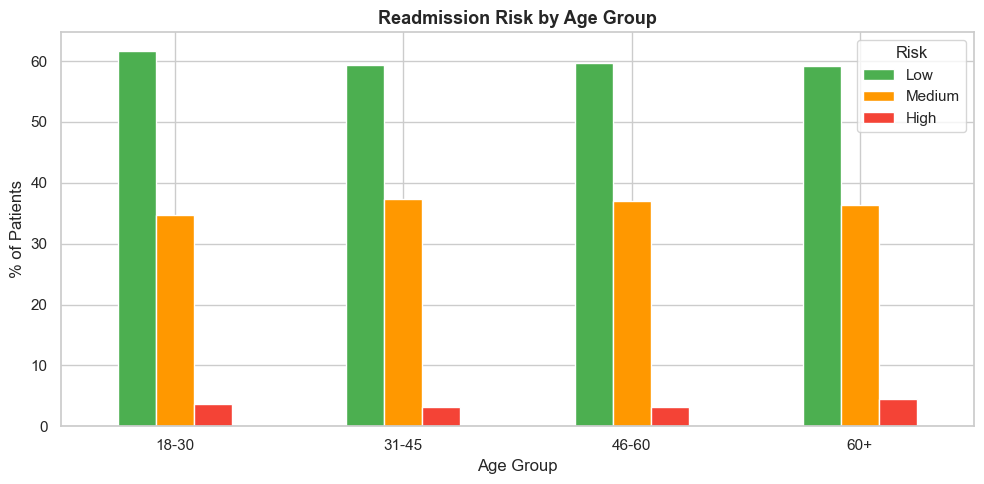

In [64]:
# Risk by age group — grouped bar
risk_age = df.groupby(['age_group', 'readmission_risk']).size().unstack(fill_value=0)
risk_age_pct = risk_age.div(risk_age.sum(axis=1), axis=0) * 100
risk_age_pct = risk_age_pct[['Low', 'Medium', 'High']]

risk_age_pct.plot(kind='bar', figsize=(10, 5),
                  color=['#4caf50', '#ff9800', '#f44336'],
                  edgecolor='white')
plt.title('Readmission Risk by Age Group', fontsize=13, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('% of Patients')
plt.legend(title='Risk')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/charts/13_risk_by_age.png', dpi=120, bbox_inches='tight')
plt.show()

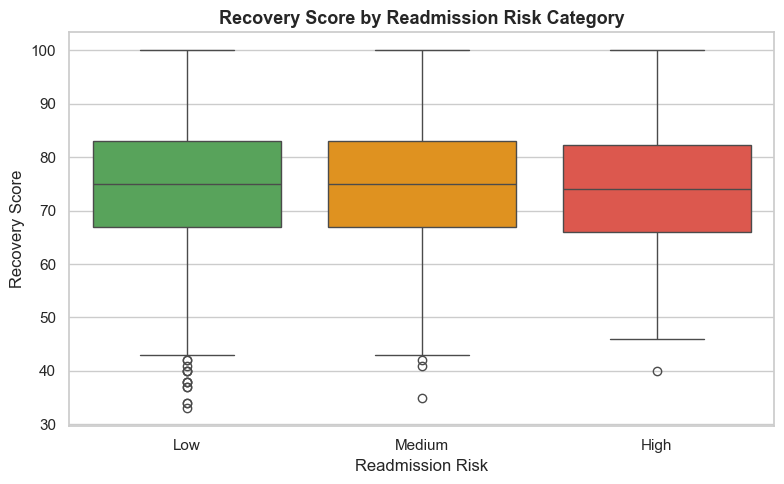

Note: Recovery scores overlap substantially across risk categories, confirming the low correlation.


In [65]:
# Recovery score by risk category
plt.figure(figsize=(8, 5))
risk_order = ['Low', 'Medium', 'High']
sns.boxplot(data=df, x='readmission_risk', y='recovery_score',
            order=risk_order, palette=['#4caf50', '#ff9800', '#f44336'])
plt.title('Recovery Score by Readmission Risk Category', fontsize=13, fontweight='bold')
plt.xlabel('Readmission Risk')
plt.ylabel('Recovery Score')
plt.tight_layout()
plt.savefig('../reports/charts/14_recovery_vs_risk.png', dpi=120, bbox_inches='tight')
plt.show()

print('Note: Recovery scores overlap substantially across risk categories, confirming the low correlation.')

---
## Summary KPI Table

In [66]:
kpis = {
    'Total Patients': f"{df['patient_id'].nunique():,}",
    'Total Visits': f"{len(df):,}",
    'Total Treatment Cost': f"${df['treatment_cost'].sum():,.0f}",
    'Avg Treatment Cost': f"${df['treatment_cost'].mean():,.0f}",
    'Avg Length of Stay': f"{df['length_of_stay_days'].mean():.2f} days",
    'Avg Recovery Score': f"{df['recovery_score'].mean():.2f}",
    'High Risk %': f"{(df['readmission_risk']=='High').sum()/len(df)*100:.1f}%",
}

for k, v in kpis.items():
    print(f'{k:<30} {v}')

Total Patients                 5,000
Total Visits                   5,000
Total Treatment Cost           $274,577,359
Avg Treatment Cost             $54,915
Avg Length of Stay             4.06 days
Avg Recovery Score             74.72
High Risk %                    3.5%
